#### Summary: 
In this notebook we perform enrichment analyses for eQTLs in cREs linked to genes (that select the same target gene). These analyses are done on sets of links binned by distances, as well as sets of significant links found by multiple methods. 

- Significant sets: all links within distance bins, subsampled down to match size of background set if larger
- Background sets: all links within same distance bins, subsampled down to match size of significant set if larger
- After everything removes thresholded files to save space
- Optional section that prints out eQTL overlap and concordance tables for visualization

# 1. Basic Preparation

In [1]:
# Import necessary libraries
suppressMessages(library(tidyverse))
suppressMessages(library(stringr))
suppressMessages(library(data.table))
suppressMessages(library(grid))

suppressMessages(library(tictoc))
suppressMessages(library(UpSetR))
suppressMessages(library(cicero))
suppressMessages(library(pheatmap))
suppressMessages(library(RColorBrewer))

suppressMessages(library(parallel))

In [2]:
# Define celltypes list
celltypes <- c('beta','alpha','delta','gamma','acinar','ductal')

# Define colors for each celltype (same order as celltypes)
colors <- c('#3F98E0', '#F51646', '#E39E14', '#A1D99B', '#F5DE6C', '#09850B')

In [179]:
# Define names and colors for link methods
link_methods <- c('sm', 'sl', 'abc', 'cic')
link_colors <- c('#B35D91', '#56B05C', '#4568A8', '#D8C45E')
names(link_colors) <- alink_methods

# Define overlap sets and colors
overlap_colors <- c('sm_sl_abc_cic'='#000000',
                    'sl_abc_cic'='#6E9183','sm_sl_cic'='#A58C77','sm_sl_abc'='#81758A','sm_abc_cic'='#867D90',
                    'sl_cic'='#97BA5D','sl_abc'='#4E8C82','abc_cic'='#8F9683','sm_sl'='#858777','sm_cic'='#C69178','sm_abc'='#7C639D',
                    'sl'='#56B05C','cic'='#D8C45E','abc'='#4568A8','sm'='#B35D91')
link_sets <- names(overlap_colors)

In [4]:
distance_bins <- c('100000-250000', '50000-100000', '10000-50000', '0-10000')

In [5]:
# disable scientific notation for the filepath names of larger distances
options(scipen = 999)
set.seed(8)

### Important file paths

In [6]:
links_dir <- "/dir/with/processed/cRE-gene/links"

In [8]:
overlap_prefix <- file.path(links_dir,'combined/')
overlap_suffix1 <- '_all_methods_sig_links.bedpe'
overlap_suffix2 <- '_all_methods_bg_links.bedpe'

In [9]:
outdir <- '/dir/to/save/eQTL_overlaps'

### Define necessary reference files

In [10]:
# read in the gene coords ref file
ref_df <- read.table('non-diabetic-islet-multiomics/references/gene_coords.gencodev32.hg38.bed', sep='\t', header=FALSE) #read in gene coords ref
promoter_df <- read.table('non-diabetic-islet-multiomics/references/gene_coords.gencodev32.hg38.TSS500bp.bed', sep='\t', header=FALSE) #read in promoter ref

# 2. Process the eQTL data
Obtain the eQTL data you want to use as the "ground truth" set to compare enrichment in. The eQTL data should be only significant results, have SNPs in start-0 hg38 coords and be in a bed file with the following information: `chr#	start	end	rsID	pvalue	effect	qvalue	gene_name`. In this study we use eQTL data from bulk pancreatic islets generated by the InsPIRE consortium -- [Vinuela et al. (2020)](https://www.nature.com/articles/s41467-020-18581-8).

In [11]:
# Input file
eqtl_dir <- '/dir/with/eqtl/data'
eqtl_fp  <- file.path(eqtl_dir,'sig_start0_eQTL.bed')

# 3. Identify links that overlap an eQTL (in the cRE)

### Functions

In [12]:
### Select for all links which have CREs that overlap an islet eQTL (for ANY input link bedpe)
### Save relevant eQTL information too (target gene, etc)
get_linkedCRE_eQTL_overlaps <- function(links_fp, eqtl_fp, out_fp){
    # Use bedtools intersect 
    cmd <- sprintf('bedtools intersect -a %s -b %s -wa -wb > %s', links_fp, eqtl_fp, out_fp)
    system(cmd)
}

### Generate eQTL overlapping links sets (gzip output files to save space)

In [16]:
# For each cell type overlap the combined file with eQTLs
for (celltype in celltypes){
    print(c(celltype,Sys.time()))
    in_fp <- paste0(overlap_prefix,celltype,overlap_suffix1)
    out_fp <- file.path(outdir, sprintf('%s_all_methods_sig_links.islet_eQTL_hg38_p0.00001.overlap.bed',celltype))
    get_linkedCRE_eQTL_overlaps(in_fp, eqtl_fp, out_fp)
}

[1] "beta"            "1733428192.8584"
[1] "alpha"            "1733428193.96578"
[1] "delta"            "1733428195.01568"
[1] "gamma"            "1733428196.02507"
[1] "acinar"           "1733428196.99177"
[1] "ductal"           "1733428198.01789"


In [17]:
# Also do this for the background files
for (celltype in celltypes){
    print(c(celltype,Sys.time()))
    in_fp <- paste0(overlap_prefix,celltype,overlap_suffix2)
    out_fp <- file.path(outdir, sprintf('%s_all_methods_bg_links.islet_eQTL_hg38_p0.00001.overlap.bed',celltype))
    get_linkedCRE_eQTL_overlaps(in_fp, eqtl_fp, out_fp)
}

[1] "beta"             "1733428199.21806"
[1] "alpha"            "1733428201.36324"
[1] "delta"            "1733428203.61343"
[1] "gamma"            "1733428205.80894"
[1] "acinar"           "1733428207.98282"
[1] "ductal"           "1733428210.14008"


# 4. eQTL enrichment for link method overlap sets

### Functions

In [75]:
### Function to compare genes between sig and eQTLs
compare_genes <- function(df_row){
    return(df_row[['V7']] == df_row[['V17']])
}

### Function that the permutations can call to subsample a bg links set and calculate gene concordance
get_links_eqtl_concordance <- function(x, links_df, num_links){
    links_df_fin <- links_df[sample(dim(links_df)[1], num_links),]  
    links_df_fin$gene_match <- unlist(apply(links_df_fin, 1, compare_genes))
    return(sum(links_df_fin$gene_match))
}

In [93]:
### Get the number of concordant eQTLs in linked CREs for significant and background links
### N dictates how many permutations to do (permutes whichever set is larger)
get_eqtl_concordance <- function(method_set, sig_links, bg_links, min_links=10, N=100){
    # Check if we have links before proceeding
    if (dim(sig_links)[1]<10){
        print(paste('Not enough significant links found in link method set:', method_set))
        return(c(method_set,dim(sig_links)[1],NA,NA,NA))
    } else {
        # Remove any significant links from the background (just in case weren't previously removed)
        sig_links$link <- paste(paste(sig_links$V1, sig_links$V2, sig_links$V3, sep="-"), sig_links$V7, sep='_')
        bg_links$link <- paste(paste(bg_links$V1, bg_links$V2, bg_links$V3, sep="-"), bg_links$V7, sep='_')
        bg_links_cut <- bg_links[!bg_links$link %in% sig_links$link,]   
        
        # If more bg links than sig links, subsample and calculate gene match many times
        if (dim(bg_links_cut)[1] > dim(sig_links)[1]){
            bg_gene_matches <- unlist(mclapply(seq(1,N), get_links_eqtl_concordance, bg_links_cut, dim(sig_links)[1], mc.cores=10))
            bg_gene_match <- round(mean(bg_gene_matches)) #need ints for stats

            # Also calculate gene matches for the significant peaks
            sig_links$gene_match <- unlist(apply(sig_links, 1, compare_genes))
            sig_gene_match <- sum(sig_links$gene_match)
            num_links <- dim(sig_links)[1]
            
        # Otherwise permute subsampling for the significant links set
        } else {
            print(paste('Less background links than significant!', signif_links_fp, all_links_fp))
            bg_links_cut$gene_match <- unlist(apply(bg_links_cut, 1, compare_genes))
            bg_gene_match <- sum(bg_links_cut$gene_match)
            num_links <- dim(bg_links_cut)[1]
            
            sig_gene_matches <- unlist(mclapply(seq(1,N), get_links_eqtl_concordance, sig_links, dim(bg_links_cut)[1], mc.cores=10))
            sig_gene_match <- round(mean(sig_gene_matches))
        }

        # Organize outputs and return
        outlist <- c(method_set, num_links, sig_gene_match, num_links, bg_gene_match)
        return(outlist)
    }
}

In [95]:
### Basic function to run Fisher's exact test for enrichment using an input data.table (2 x 2)
### Returns vector of (CI left side, odds ratio, CI right side, pvalue)
test_eqtl_enrichment <- function(df_row){
    # Set up data table (2 x 2) for test
    data <- data.frame('links_match'=c(as.numeric(df_row[['signif_genes_match_eQTL']]), as.numeric(df_row[['nonsignif_genes_match_eQTL']])),
                        'total_links'=as.numeric(c(df_row[['signif_links']]), as.numeric(df_row[['nonsignif_links']])),
                        row.names=c('signif_links','nonsignif_links'))
    data_fin <- as.matrix(data)
    test <- fisher.test(data_fin)
    vector <- c(test$conf.int[1], test$estimate, test$conf.int[2], test$p.value)
    return(vector)
}


### Function to read in eQTL concordance outputs and calculate fischer's enrichment for all method sets
calculate_all_eqtl_enrichment <- function(df){
    # Run Fisher's exact test for each row in each df_fin that isn't NA
    non_na <- subset(df, !is.na(signif_genes_match_eQTL))
    tests <- apply(non_na, 1, test_eqtl_enrichment)
    test_results <- as.data.frame(t(tests))
    colnames(test_results) <- c('CI_L','odds_ratio','CI_R','pval')
    test_results$method_set <- non_na$method_set
    return(test_results)        
}

In [97]:
### Overall enrichment wrapper
wrapper_eqtl_enrichment_method_bins <- function(celltype, method_strs, outdir){
    # First read in the eQTL overlap result file paths (sig and bg)
    sig_fp <- file.path(outdir, sprintf('%s_all_methods_sig_links.islet_eQTL_hg38_p0.00001.overlap.bed.gz',celltype))
    sig_links <- fread(sig_fp)
    bg_fp <- file.path(outdir, sprintf('%s_all_methods_bg_links.islet_eQTL_hg38_p0.00001.overlap.bed.gz',celltype))
    bg_links <- fread(bg_fp)
    
    # Then test for eQTL concordance for each method overlap set
    overlap_df <- data.frame()
    for (method_set in method_strs){
        sig_links_sub <- subset(sig_links, V9==method_set)
        results <- get_eqtl_concordance(method_set, sig_links_sub, bg_links)
        overlap_df <- rbind(overlap_df, results)
    }
    
    # A few modifications to the overlap dataframe and write out
    colnames(overlap_df) <- c('method_set','signif_links','signif_genes_match_eQTL','nonsignif_links','nonsignif_genes_match_eQTL')
    out_fp <- file.path(outdir, 'method_sets_enrichment', sprintf('%s_eQTL_overlap_concordance.link_method_sets.txt', celltype))
    write.table(overlap_df, out_fp, sep='\t', row.names = FALSE, col.names = TRUE, quote=FALSE)

    # Now calculate enrichment with Fischer's test
    enrichment_res <- calculate_all_eqtl_enrichment(overlap_df)
    out_fp2 <- file.path(outdir, 'method_sets_enrichment', sprintf('%s_eQTL_overlap_concordance.link_method_sets.Fishers_enrichment.txt',celltype))
    write.table(enrichment_res, out_fp2, sep='\t', col.names=TRUE, row.names=FALSE, quote=FALSE)
}

### Calculate enrichment of concordant eQTLs

In [99]:
for(celltype in celltypes){
    print(celltype)
    wrapper_eqtl_enrichment_method_bins(celltype, link_sets, outdir)
}

[1] "Not enough significant links found in link method set: sm_sl_abc_cic"
[1] "Not enough significant links found in link method set: sl_abc_cic"
[1] "Not enough significant links found in link method set: sm_sl_cic"
[1] "Not enough significant links found in link method set: sm_sl_abc_cic"
[1] "Not enough significant links found in link method set: sl_abc_cic"
[1] "Not enough significant links found in link method set: sm_sl_cic"
[1] "Not enough significant links found in link method set: sm_sl_abc_cic"
[1] "Not enough significant links found in link method set: sm_sl_cic"
[1] "Not enough significant links found in link method set: sm_abc_cic"
[1] "Not enough significant links found in link method set: sm_sl"
[1] "Not enough significant links found in link method set: sm_sl_abc_cic"
[1] "Not enough significant links found in link method set: sm_sl_cic"
[1] "Not enough significant links found in link method set: sm_sl_abc"
[1] "Not enough significant links found in link method set: sm

# 5. eQTL enrichment thresholded by distance (separate method sets)

### Functions (reusing some from previous section, so make sure to rerun those blocks!)

In [121]:
### Function to calculate link distances from a bedpe style dataframe row
calc_link_distance <- function(link_df_row){
    CRE_start <- as.integer(link_df_row[2])
    CRE_end <- as.integer(link_df_row[3])
    gene_start <- as.integer(link_df_row[5])
    CRE_center <- CRE_start + (CRE_end - CRE_start)/2
    distance <- as.integer(abs(CRE_center - gene_start))
    return(distance)
}


### Function to figure out which distance bin a distance fits in
classify_distance_bin <- function(distance, distance_bins){
    min_dists <- as.numeric(str_split_fixed(distance_bins, '-', 2)[,1])
    max_dists <- as.numeric(str_split_fixed(distance_bins, '-', 2)[,2])
    min_in_bins <- (distance > min_dists)
    max_in_bins <- (distance < max_dists)
    both_true <- (min_in_bins & max_in_bins)
    bin <- distance_bins[which(both_true==TRUE)]
    return(bin)
}

In [129]:
### Overall enrichment wrapper
wrapper_eqtl_enrichment_distance_bins <- function(celltype, methods, distance_bins, outdir){
    # First read in the eQTL overlap result file paths (sig and bg)
    sig_fp <- file.path(outdir, sprintf('%s_all_methods_sig_links.islet_eQTL_hg38_p0.00001.overlap.bed.gz',celltype))
    sig_links <- fread(sig_fp)
    bg_fp <- file.path(outdir, sprintf('%s_all_methods_bg_links.islet_eQTL_hg38_p0.00001.overlap.bed.gz',celltype))
    bg_links <- fread(bg_fp)

    # Next calculate the distance for each link and assign to a distance bin
    sig_links$distance <- unlist(apply(sig_links, 1, calc_link_distance))
    sig_links$dist_bin <- sapply(sig_links$distance, classify_distance_bin, distance_bins)
    bg_links$distance <- unlist(apply(bg_links, 1, calc_link_distance))
    bg_links$dist_bin <- sapply(bg_links$distance, classify_distance_bin, distance_bins)
    
    # Then test for eQTL concordance for each method AND distance bin
    overlap_df <- data.frame()
    for (method in methods){
        for(dist in distance_bins){
            method_set <- paste(method, dist, sep='_')
            sig_links_sub <- subset(sig_links, grepl(method, V9) & dist_bin==dist)
            bg_links_sub <- subset(bg_links, dist_bin==dist)
            results <- get_eqtl_concordance(method_set, sig_links_sub, bg_links_sub)
            overlap_df <- rbind(overlap_df, results)
        }
    }

    # A few modifications to the overlap dataframe and write out
    colnames(overlap_df) <- c('method_set','signif_links','signif_genes_match_eQTL','nonsignif_links','nonsignif_genes_match_eQTL')
    out_fp <- file.path(outdir, 'distance_bins_enrichment', sprintf('%s_eQTL_overlap_concordance.link_distance_bins.txt', celltype))
    write.table(overlap_df, out_fp, sep='\t', row.names = FALSE, col.names = TRUE, quote=FALSE)

    # Now calculate enrichment with Fischer's test
    enrichment_res <- calculate_all_eqtl_enrichment(overlap_df)
    out_fp2 <- file.path(outdir, 'distance_bins_enrichment', sprintf('%s_eQTL_overlap_concordance.link_distance_bins.Fishers_enrichment.txt',celltype))
    write.table(enrichment_res, out_fp2, sep='\t', col.names=TRUE, row.names=FALSE, quote=FALSE)
}

### Calculate enrichment of concordant eQTLs in different distance bins

In [182]:
methods <- c('sm','sl','abc','cic')
for(celltype in celltypes){
    print(celltype)
    wrapper_eqtl_enrichment_distance_bins(celltype, methods, distance_bins, outdir)
}

[1] "beta"
[1] "alpha"
[1] "delta"
[1] "gamma"
[1] "acinar"
[1] "ductal"


# 6. Plot results

### Functions

In [177]:
### dedicated plotting function
plot_enrichment_comp_fin <- function(fp, xmax, ordered_method_sets, colors, title){
    # Read in table of Fisher's exact test odd's ratios and CIs
    data <- read.table(fp, sep='\t', header = TRUE)
    row.names(data) <- data$method_set
    data_cut_sort <- data[order(data$method_set),]
    
    # Set any values outside of xmax to the limits (also record which values exceed the limits)
    past_xmax <- row.names(data_cut_sort[data_cut_sort$CI_R > xmax,])
    data_cut_sort[past_xmax, 'CI_R'] <- xmax
    or_past_xmax <- row.names(data_cut_sort[data_cut_sort$odds_ratio > xmax,])
    
    # Prepare input vectors for arrows 
    data_cut_sort$max_arrow_L <- NA 
    data_cut_sort[past_xmax, 'max_arrow_L'] <- data_cut_sort[past_xmax,'odds_ratio'] + 0.5
    data_cut_sort$max_arrow_R <- NA
    data_cut_sort[past_xmax, 'max_arrow_R'] <- xmax
    if (length(or_past_xmax) > 0){
        print(or_past_xmax)
        data_cut_sort[or_past_xmax, 'max_arrow_L'] <- NA
        data_cut_sort[or_past_xmax, 'max_arrow_R'] <- NA
    }
    
    # Prepare strings for y-labels (get rid of underscore in rownames)
    y_labels <- rev(gsub('_', ' ', data_cut_sort$method_set))
        
    # Make a forest plot with the subsetted data
    #print(data_cut_sort)
    options(repr.plot.width = 12, repr.plot.height = 8)
    theme_set(
        theme_classic())

    p1 <- ggplot(data=data_cut_sort, aes(x=odds_ratio, y=method_set, group=celltype)) + 
            geom_vline(xintercept=seq(0, xmax, 1), linetype='dashed', color='black', alpha=0.5, size=0.5) + 
            geom_linerange(aes(xmin=CI_L, xmax=CI_R), size=0.75) + 
            geom_point(aes(x=odds_ratio), size=10, color=colors[data_cut_sort$method_set]) + 
            scale_color_manual() + xlim(0,xmax) + 
            # scale_y_discrete(labels=y_labels) + 
            xlab('Enrichment Odds Ratio (OR)') + ylab('Link set') + labs(title=title) + 
            theme(plot.title=element_text(size=20, hjust=0.5),
                  axis.text.x=element_text(size=20, vjust=0.5),
                  axis.text.y=element_text(size=20, vjust=0.5),
                  axis.title.x = element_text(size=20, vjust=-0.35),
                  axis.title.y = element_text(size=20, vjust=0.5),
                  legend.position = "none")
    if(length(past_xmax) > 0){
        p1 <- p1 + geom_segment(aes(x=max_arrow_L, xend=max_arrow_R, y=row.names(data_cut_sort), yend=row.names(data_cut_sort)),
                                lineend = 'butt', linejoin='mitre', size = 0.75, 
                                 arrow = arrow(length = unit(0.03, "npc")))
    }
    p1$data$method_set <- factor(x = p1$data$method_set, levels=rev(ordered_method_sets))
    print(p1)
}

### Make plots for link overlap sets results

Warning message:
"Removed 8 rows containing missing values (`geom_segment()`)."


[1] "sm_abc_cic"


Warning message:
"Removed 9 rows containing missing values (`geom_segment()`)."


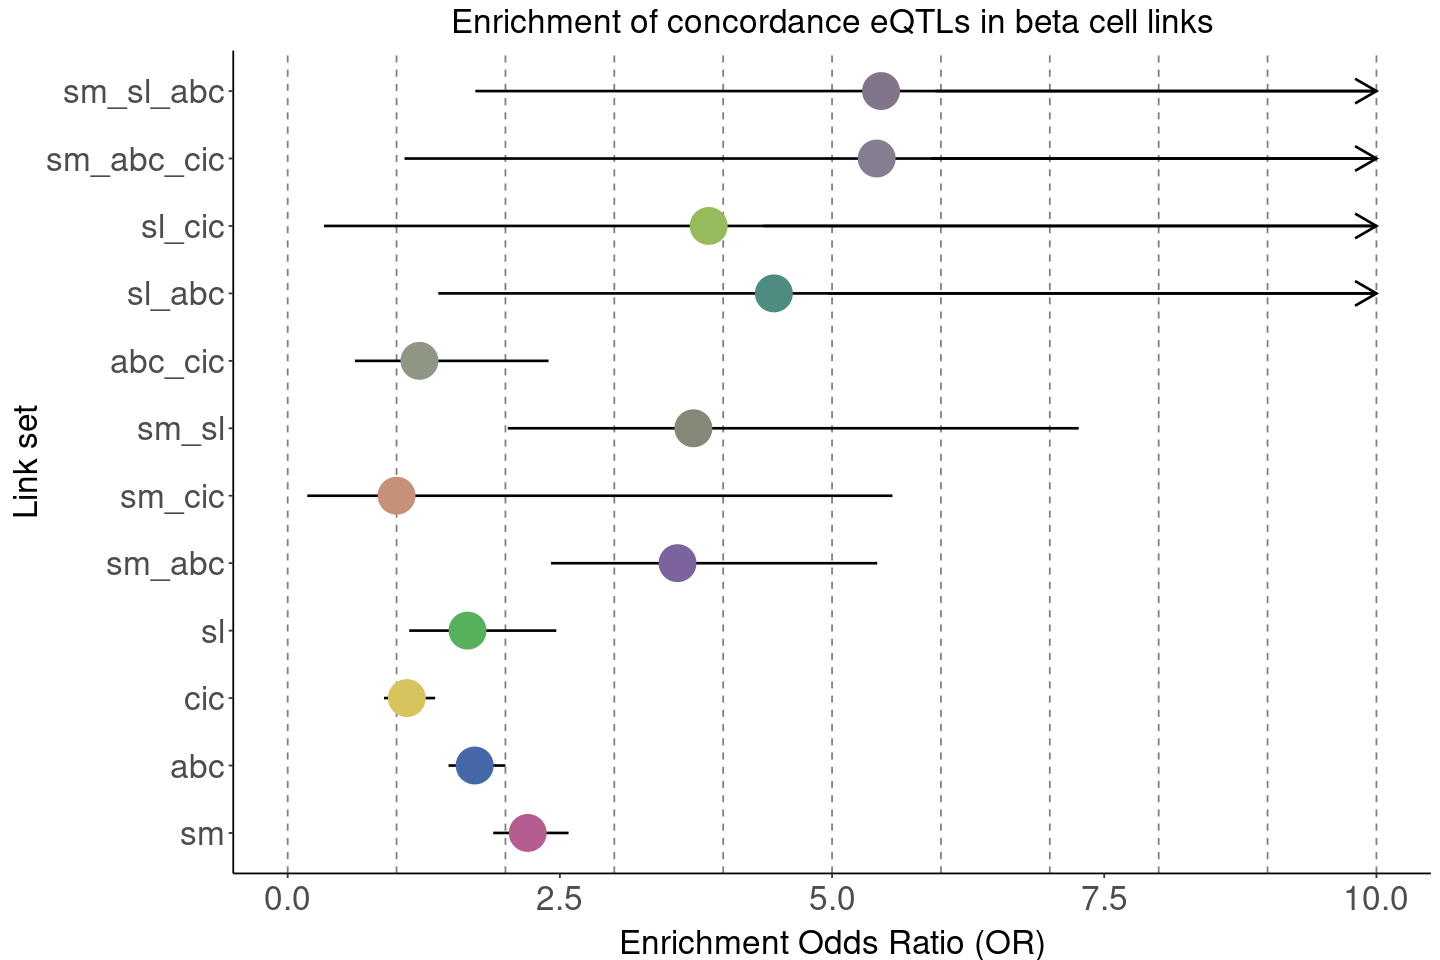

[1] "sl_abc_cic"


Warning message:
"Removed 6 rows containing missing values (`geom_segment()`)."


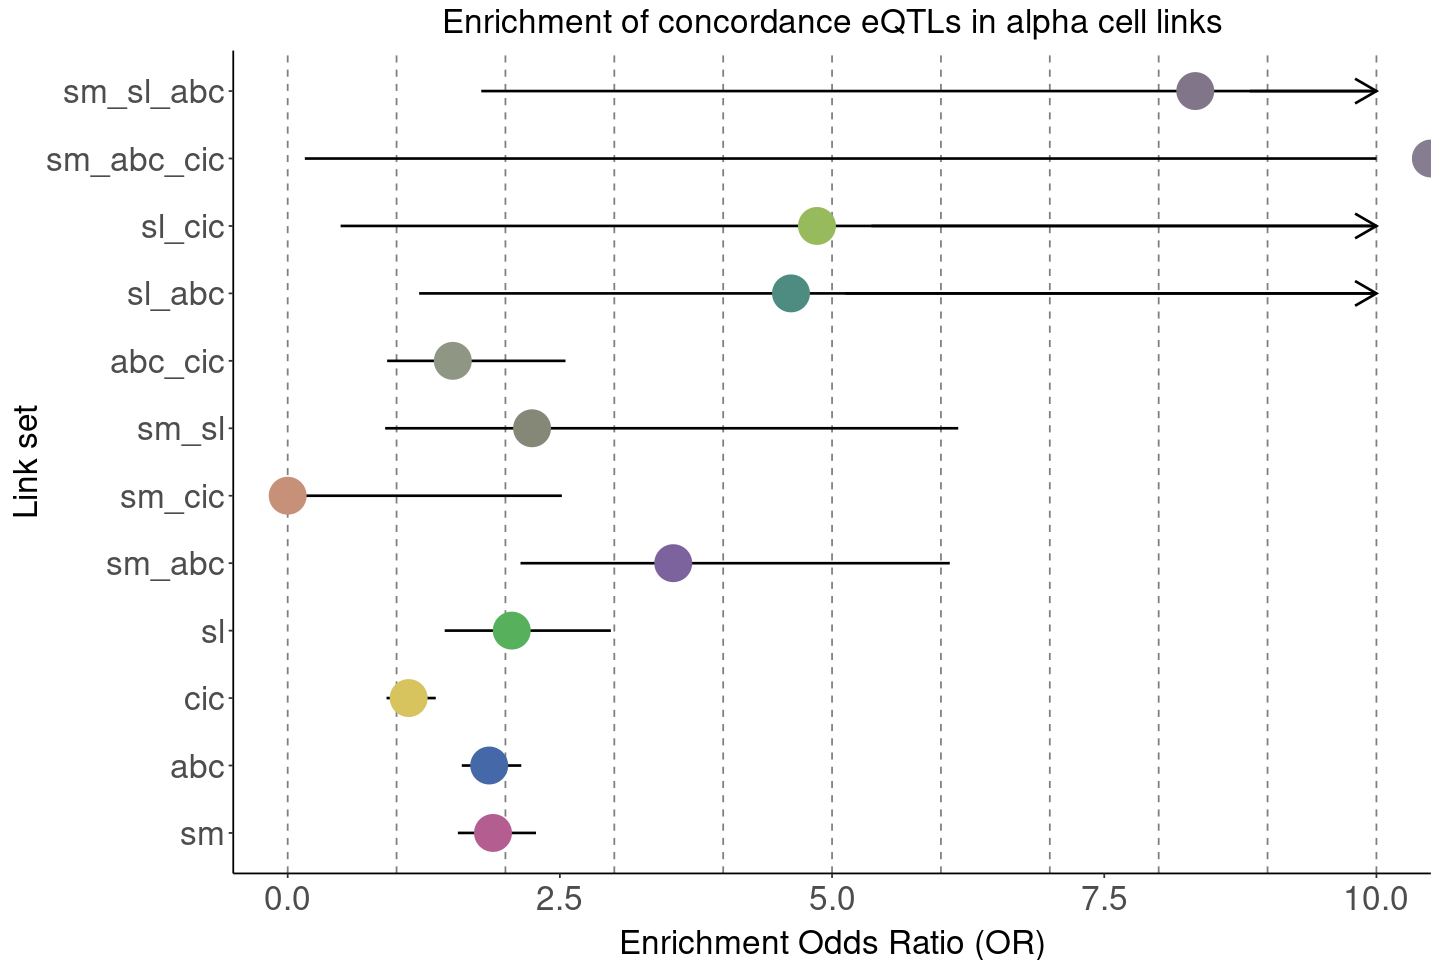

Warning message:
"Removed 6 rows containing missing values (`geom_segment()`)."


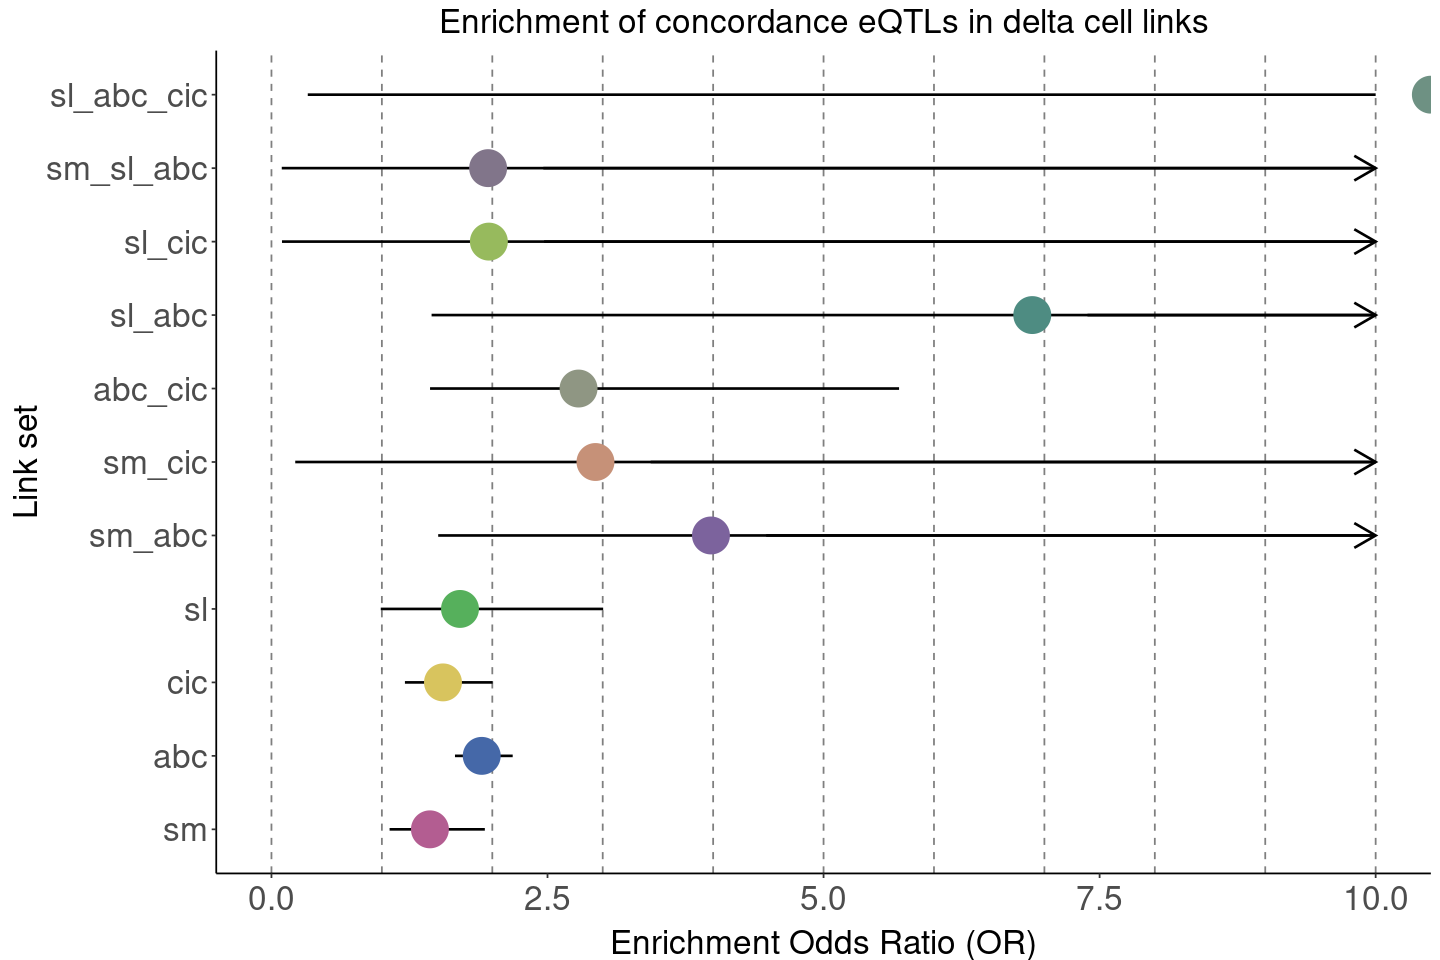

Warning message:
"Removed 7 rows containing missing values (`geom_segment()`)."


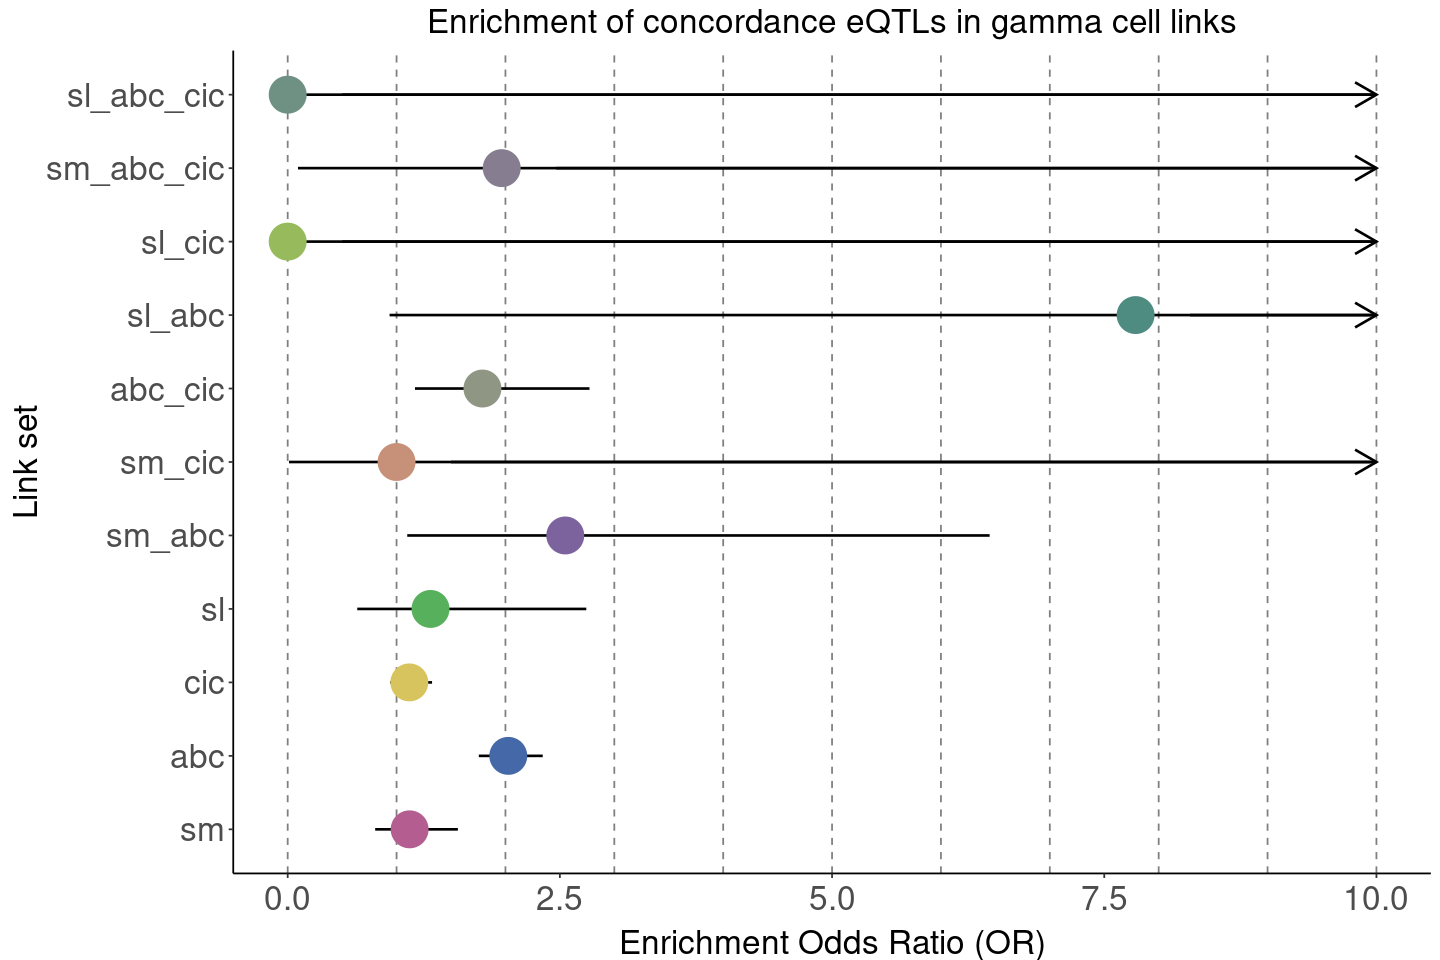

[1] "sm_sl_abc"


Warning message:
"Removed 7 rows containing missing values (`geom_segment()`)."


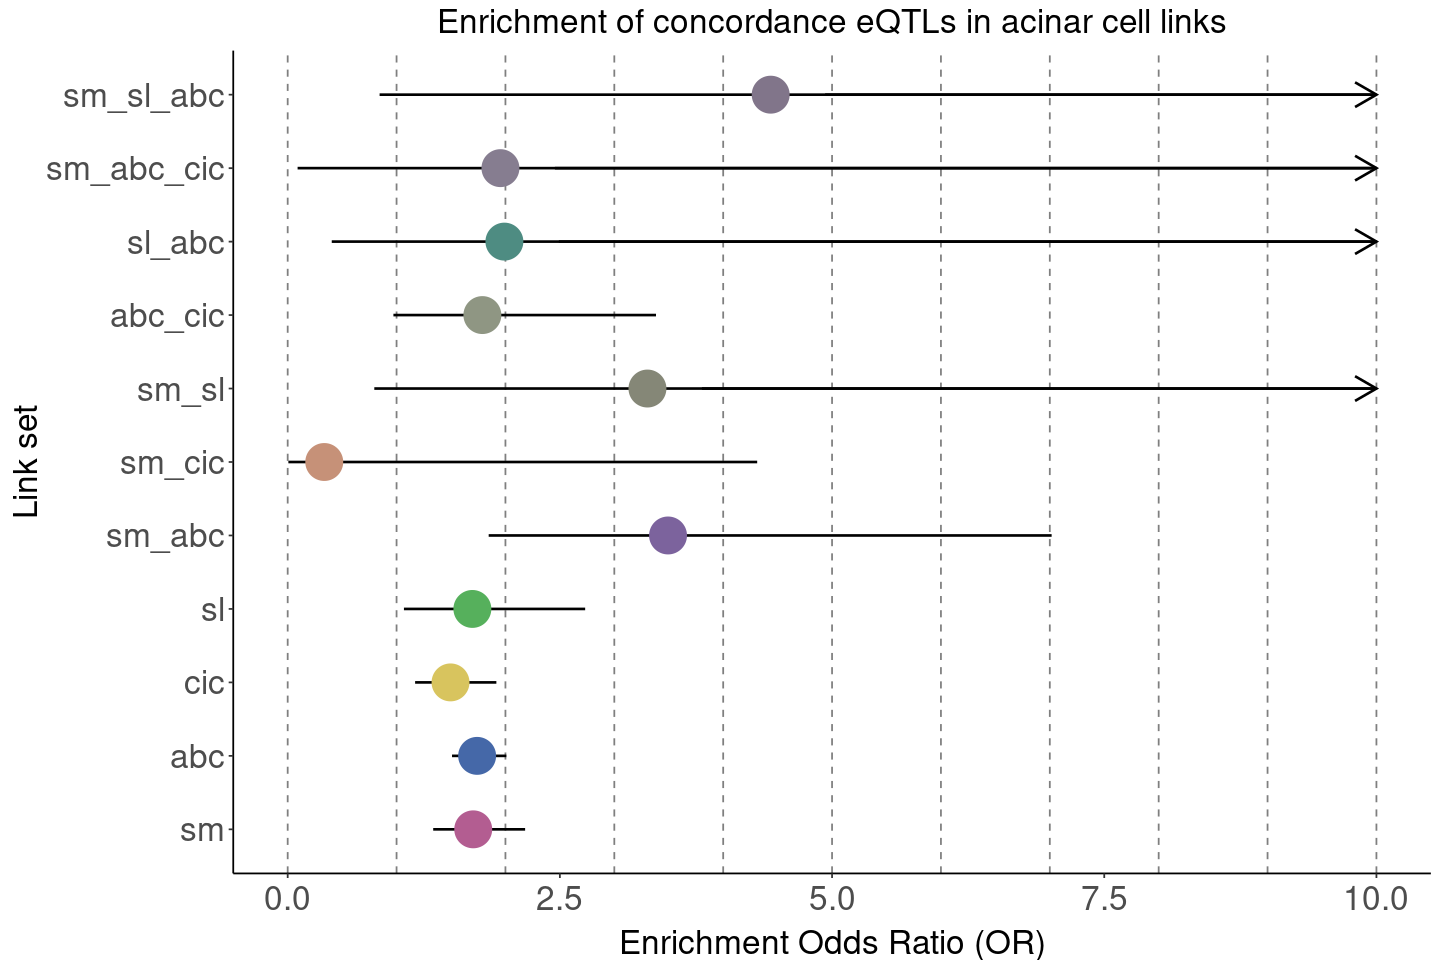

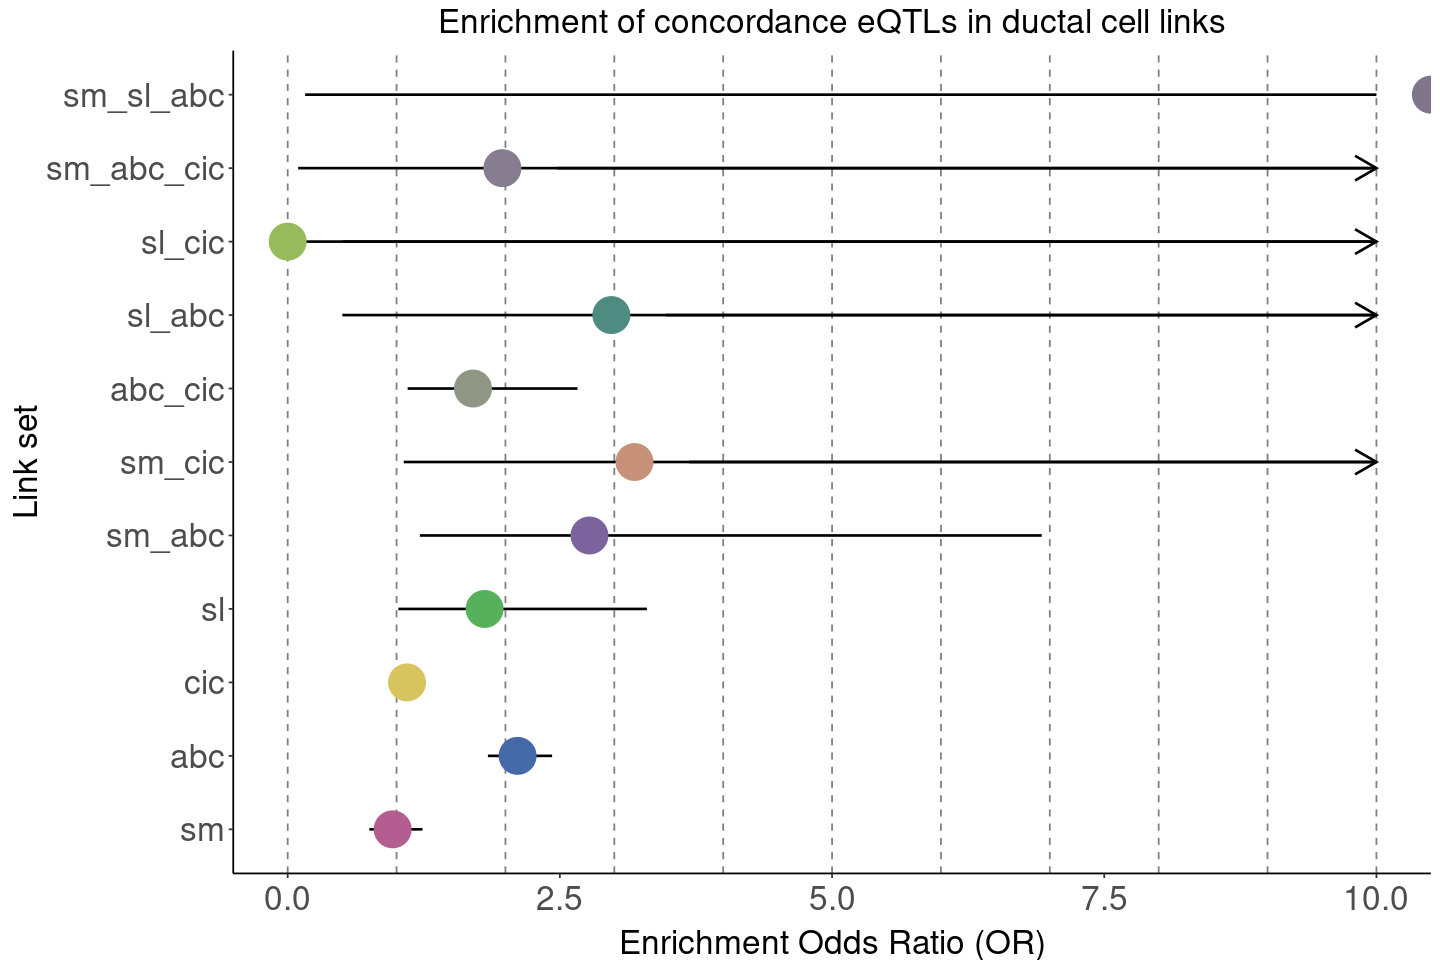

In [178]:
for(celltype in celltypes){
    fp <- file.path(outdir, 'method_sets_enrichment', sprintf('%s_eQTL_overlap_concordance.link_method_sets.Fishers_enrichment.txt',celltype))
    plot_enrichment_comp_fin(fp, 10, link_sets, overlap_colors, sprintf('Enrichment of concordance eQTLs in %s cell links',celltype))
}

## Make plots for the distance bin results

In [180]:
num <- length(distance_bins)
method_colors <- c(rep(link_colors[['sm']],num), rep(link_colors[['sl']],num), rep(link_colors[['abc']],num), rep(link_colors[['cic']], num))
names(method_colors) <- paste(rep(link_methods, each=length(distance_bins)), distance_bins, sep='_')
method_colors

sm_100000-250000   sm_50000-100000    sm_10000-50000        sm_0-10000 
        "#B35D91"         "#B35D91"         "#B35D91"         "#B35D91" 
 sl_100000-250000   sl_50000-100000    sl_10000-50000        sl_0-10000 
        "#56B05C"         "#56B05C"         "#56B05C"         "#56B05C" 
abc_100000-250000  abc_50000-100000   abc_10000-50000       abc_0-10000 
        "#4568A8"         "#4568A8"         "#4568A8"         "#4568A8" 
cic_100000-250000  cic_50000-100000   cic_10000-50000       cic_0-10000 
        "#D8C45E"         "#D8C45E"         "#D8C45E"         "#D8C45E"

Warning message:
"Removed 15 rows containing missing values (`geom_segment()`)."
Warning message:
"Removed 15 rows containing missing values (`geom_segment()`)."


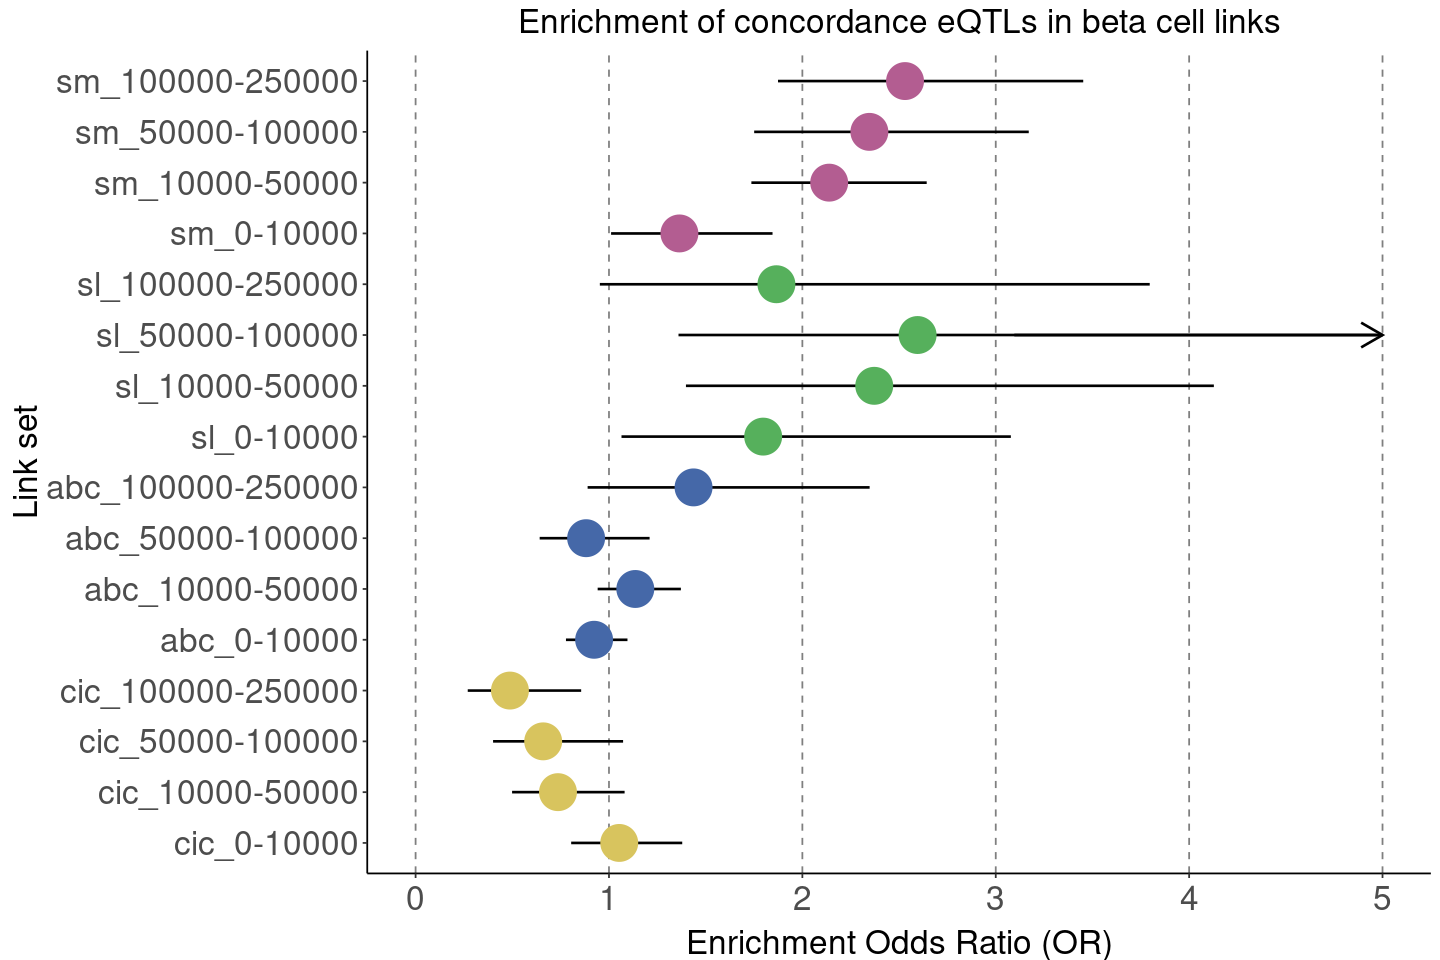

Warning message:
"Removed 15 rows containing missing values (`geom_segment()`)."


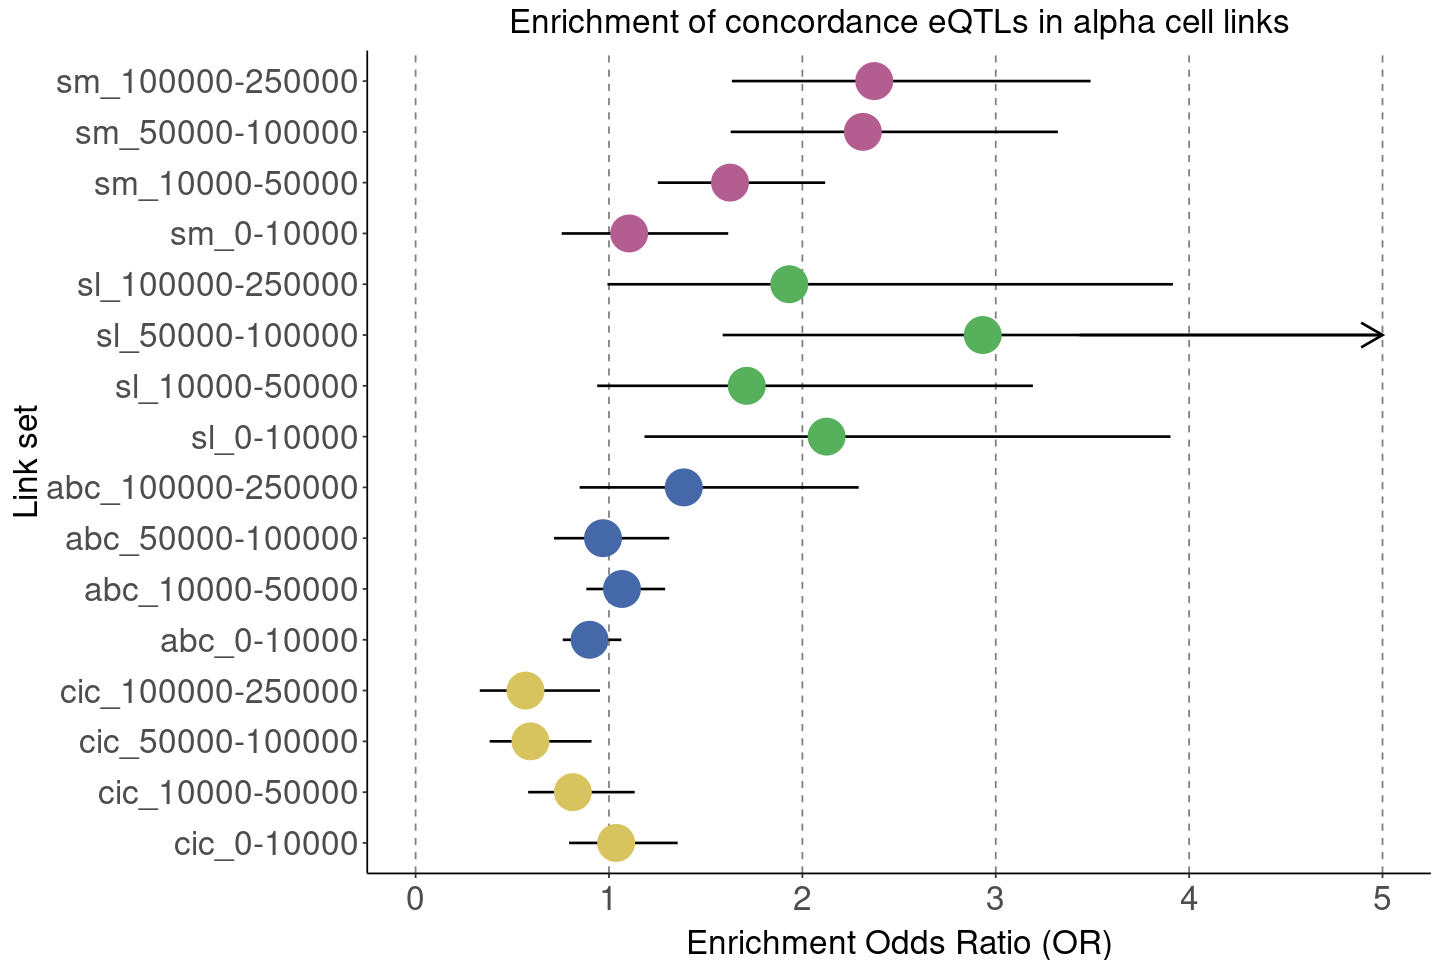

Warning message:
"Removed 14 rows containing missing values (`geom_segment()`)."


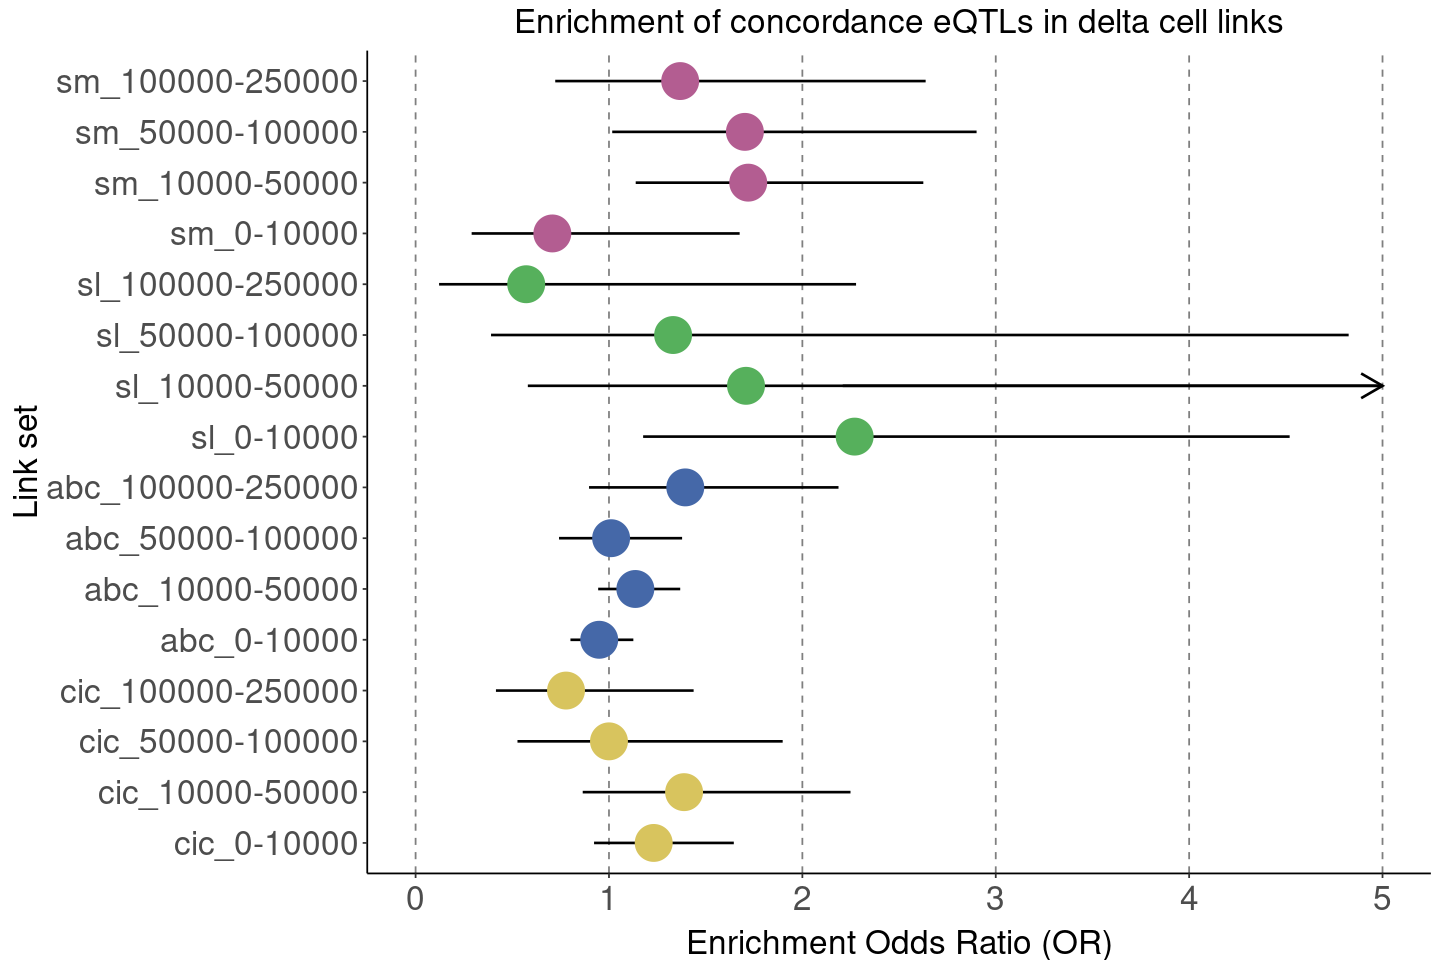

Warning message:
"Removed 15 rows containing missing values (`geom_segment()`)."


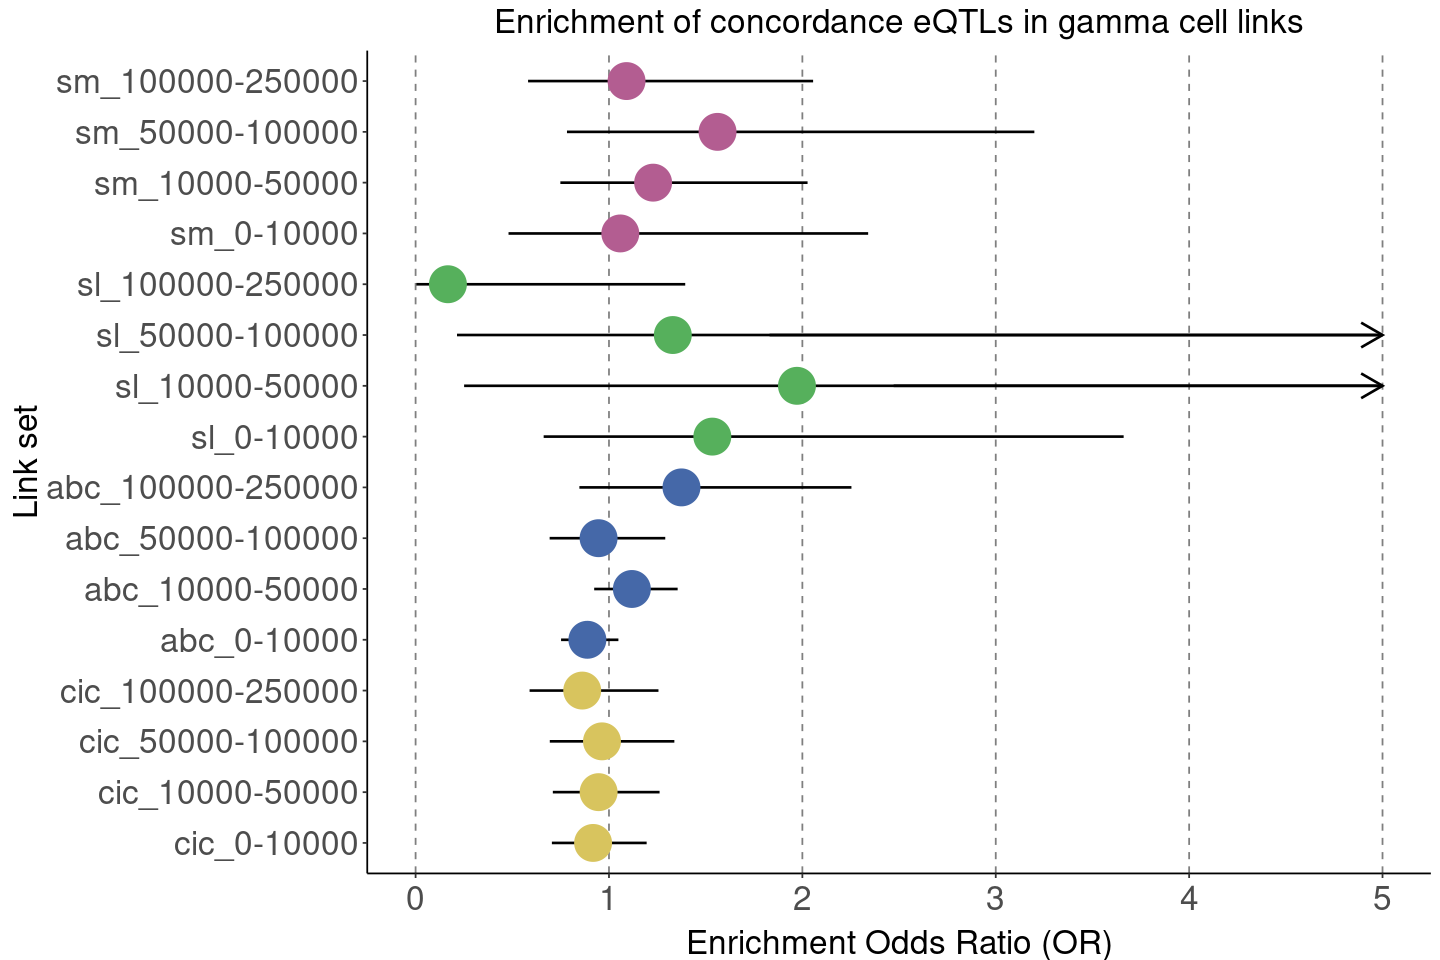

Warning message:
"Removed 14 rows containing missing values (`geom_segment()`)."


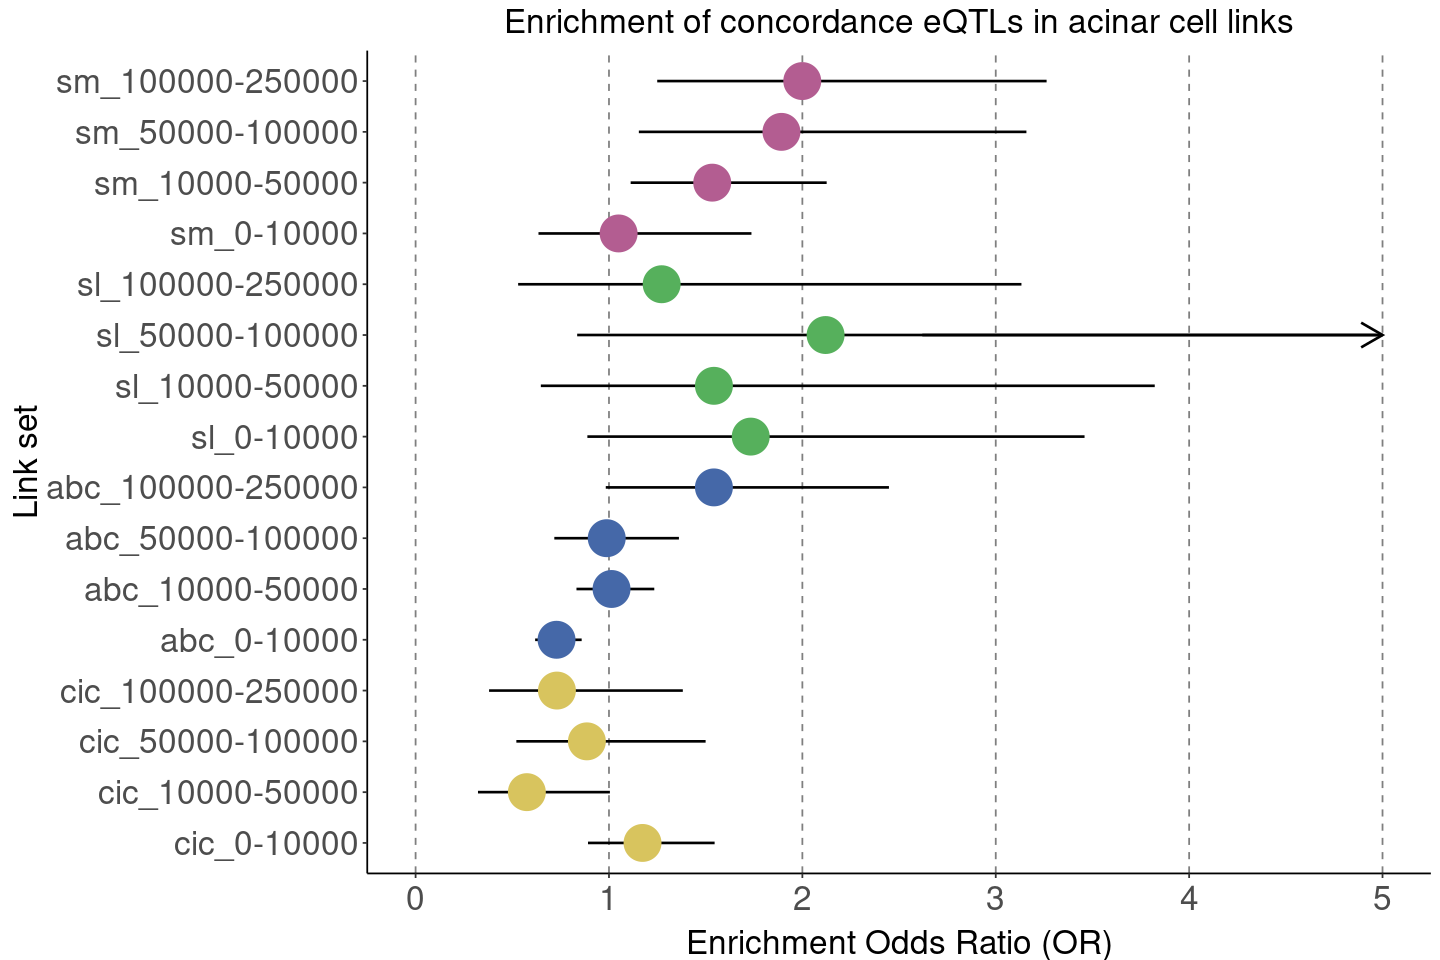

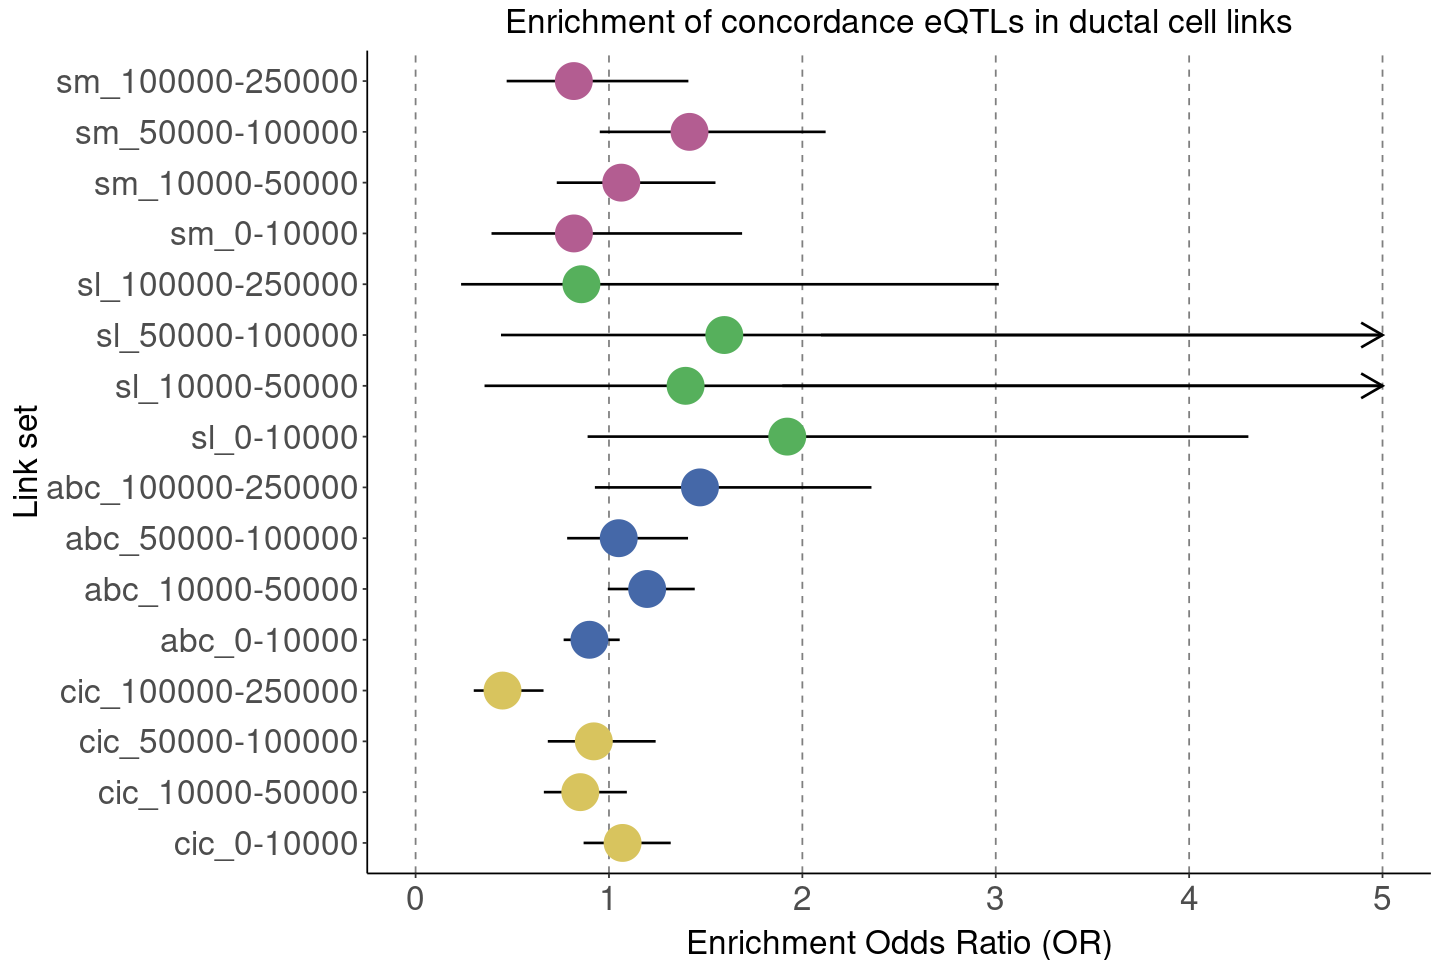

In [184]:
for(celltype in celltypes){
    fp <- file.path(outdir, 'distance_bins_enrichment', sprintf('%s_eQTL_overlap_concordance.link_distance_bins.Fishers_enrichment.txt',celltype))
    plot_enrichment_comp_fin(fp, 5, names(method_colors), method_colors, sprintf('Enrichment of concordance eQTLs in %s cell links',celltype))
}